# Import and Data filtering

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

import seaborn as sns
from matplotlib.ticker import FuncFormatter

from matplotlib.gridspec import GridSpec
from scipy.optimize import minimize
#plt.style.use('seaborn-v0_8-darkgrid')
from dashboard import PortfolioDashboardVisualizer

YIELD_IS_PERCENT = True

In [2]:
data = pd.read_csv("data/benchmark_mids_cs.csv")

# Ensure the timestamp is datetime
data["time_stamp"] = pd.to_datetime(data["time_stamp"])

# Sort by ISIN and timestamp to get the correct last entry
data = data.sort_values(["isin", "time_stamp"])

# Keep the last observation per day per ISIN
data = data.groupby(["isin", data["time_stamp"].dt.date], as_index=False).last()
data["time_stamp"] = data["time_stamp"].dt.date
data.shape

(26622, 10)

In [3]:
data.head()

,isin,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01
0,DE0001102366,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957
1,DE0001102366,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962
2,DE0001102366,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959
3,DE0001102366,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966
4,DE0001102366,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961


In [4]:
# Parse timestamp BEFORE sorting/resampling
#data["time_stamp"] = pd.to_datetime(data["time_stamp"], utc=True)

# Consistent typing on mat_cat (string is safer for column labels)
data["mat_cat"] = data["mat_cat"].astype(str)
# Sort within each contract series
data = data.sort_values(["isin", "time_stamp"]).reset_index(drop=True)

# --- Δy by ISIN (no cross-ISIN leakage) ---
# If yield is in percent (e.g., 0.4835%), convert to decimal before differencing
if YIELD_IS_PERCENT:
    y_level = data["yield"] / 100.0
else:
    y_level = data["yield"]
data["dy"] = y_level.groupby(data["isin"]).diff()  # Δy in decimal (e.g., 1 bp = 0.0001)

# Also keep Δy in bp if needed
data["dy_bp"] = data["dy"] * 1e4  # basis points

# (Futures) We will build a *risk-normalized* return per unit DV01 next.
# For IR futures, linearized PnL ≈ - DV01 * Δy. Per unit DV01, return ≈ -Δy.
# This avoids notional/DV01 scaling headaches at optimization time.
data["r_per_DV01"] = -data["dy_bp"]*data["dv01"]  # per DV01 standardized return (dimensionless)
data["daily_coupon"] = data['yield'].shift(1)*(1/252)/100 #pour enlever le pourcent  
data["total_ret"] = data["r_per_DV01"] + data["daily_coupon"] 
data.head()

,isin,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01,dy,dy_bp,r_per_DV01,daily_coupon,total_ret
0,DE0001102366,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957,NaN,NaN,NaN,NaN,NaN
1,DE0001102366,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962,-0.000435,-4.35,0.004183,0.000021,0.004204
2,DE0001102366,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959,0.000200,2.00,-0.001917,0.000020,-0.001898
3,DE0001102366,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966,-0.000715,-7.15,0.006904,0.000020,0.006924
4,DE0001102366,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961,0.000385,3.85,-0.003702,0.000018,-0.003684


C:\Users\hugoj\AppData\Local\Temp\ipykernel_7984\1640781942.py:23: FutureWarning: Comparison of Timestamp with datetime.date is deprecated in order to match the standard library behavior. In a future version these will be considered non-comparable. Use 'ts == pd.Timestamp(date)' or 'ts.date() == date' instead.
  (data["time_stamp"] >= pd.to_datetime(start_date)) &
C:\Users\hugoj\AppData\Local\Temp\ipykernel_7984\1640781942.py:24: FutureWarning: Comparison of Timestamp with datetime.date is deprecated in order to match the standard library behavior. In a future version these will be considered non-comparable. Use 'ts == pd.Timestamp(date)' or 'ts.date() == date' instead.
  (data["time_stamp"] <= pd.to_datetime(end_date))


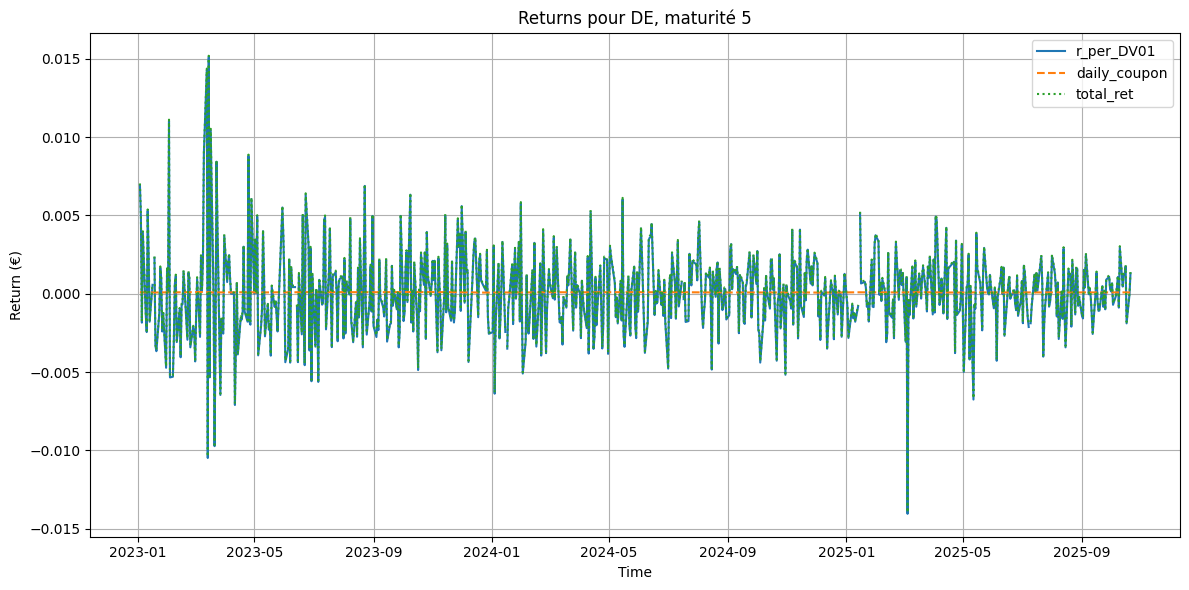

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# Variables à modifier facilement
# -----------------------------
country = "DE"                # Pays à filtrer
maturity = "5"                # Maturité à filtrer (valeur de mat_cat)
return_col1 = "r_per_DV01"   # Colonne de return DV01
return_col2 = "daily_coupon" # Colonne de coupon quotidien
return_col3 = "total_ret"    # Colonne de return total

start_date = "2023-01-01"    # Date de début du plot
end_date = "2025-12-31"      # Date de fin du plot

# -----------------------------
# Filtrage du DataFrame
# -----------------------------
df_plot = data.loc[
    (data["country_iso"] == country) &
    (data["mat_cat"] == maturity) &
    (data["time_stamp"] >= pd.to_datetime(start_date)) &
    (data["time_stamp"] <= pd.to_datetime(end_date))
]

# -----------------------------
# Plot avec matplotlib
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(df_plot["time_stamp"], df_plot[return_col1], label=return_col1, linestyle="-")
plt.plot(df_plot["time_stamp"], df_plot[return_col2], label=return_col2, linestyle="--")
plt.plot(df_plot["time_stamp"], df_plot[return_col3], label=return_col3, linestyle=":")
plt.title(f"Returns pour {country}, maturité {maturity}")
plt.xlabel("Time")
plt.ylabel("Return (€)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Bonne tête de return !

# Estimation des return

In [6]:
#On met data sous le bon format. Ce qu'on veut c'est :
# Date | Finacial product (ex FR_5 pour France bond mat 5) | Return
val = "total_ret"

data_completed = data[["time_stamp", "country_iso", "mat_cat", val]].copy()
data_completed["product"] = data_completed["country_iso"].astype(str) + "_" + data_completed["mat_cat"].astype(str)
data_completed = data_completed.drop(columns=["country_iso", "mat_cat"])
data_completed["time_stamp"] = pd.to_datetime(data_completed["time_stamp"])

data_completed.head()




,time_stamp,total_ret,product
0,2015-01-01,NaN,DE_10
1,2015-01-02,0.004204,DE_10
2,2015-01-05,-0.001898,DE_10
3,2015-01-06,0.006924,DE_10
4,2015-01-07,-0.003684,DE_10


In [7]:
"""
  # standardized return per DV01

def make_panel(df_country):
    wide = df_country.pivot(index="time_stamp", columns="mat_cat", values=val)
    # Aggregate intraday to daily by summing Δy contributions
    daily = wide#.resample("1D").sum(min_count=1)
    return daily

df_FR = make_panel(data[data["country_iso"] == "FR"])
df_DE = make_panel(data[data["country_iso"] == "DE"])
df_IT = make_panel(data[data["country_iso"] == "IT"])

# Optional: drop all-empty days only (keep pairwise NA for cov estimation later)
for k, df in [("FR", df_FR), ("DE", df_DE), ("IT", df_IT)]:
    pass  # no full dropna here; we’ll handle pairwise later
"""

'\n  # standardized return per DV01\n\ndef make_panel(df_country):\n    wide = df_country.pivot(index="time_stamp", columns="mat_cat", values=val)\n    # Aggregate intraday to daily by summing Δy contributions\n    daily = wide#.resample("1D").sum(min_count=1)\n    return daily\n\ndf_FR = make_panel(data[data["country_iso"] == "FR"])\ndf_DE = make_panel(data[data["country_iso"] == "DE"])\ndf_IT = make_panel(data[data["country_iso"] == "IT"])\n\n# Optional: drop all-empty days only (keep pairwise NA for cov estimation later)\nfor k, df in [("FR", df_FR), ("DE", df_DE), ("IT", df_IT)]:\n    pass  # no full dropna here; we’ll handle pairwise later\n'

In [8]:
class Portfolio:
    def __init__(self, data, date, benchmark="ew", long_only=True, lamb=1.0, ridge=1e-3, window_days=None, sigma_level = 0.01):
        """
        data: Pandas dataframe withe time_stamp, product, total_ret
        date: datetime-like
            Rebalance (estimation) date. Uses history up to and including this date.
        long_only: if True, project to simplex after solving (approximate).
        lamb: risk-aversion for mean-variance utility: maximize mu'w - lambda * w'Σw.
        ridge: diagonal shrinkage added to Σ for stability.
        window_days: if set, only use last N calendar days of history for μ, Σ.
        """
        self.data = data
        self.date = pd.to_datetime(date)
        self.benchmark = benchmark
        self.returns = None
        self.mean_returns = None
        self.cov_matrix = None
        self.weights = None

        self.long_only = long_only
        self.lamb = float(lamb)
        self.ridge = float(ridge)
        self.window_days = window_days
        self.benchmark_weights = None
        self.sigma_level = sigma_level

    def get_returns_until(self):
        """filter up to self.date."""
        R = self.data[self.data["time_stamp"] < self.date]

        if self.window_days is not None:
            start_cut  = self.date - pd.Timedelta(days=int(self.window_days))
            R = R[R["time_stamp"] >= start_cut]
        #print(R)
        # Do not drop to full intersection early; compute pairwise μ, Σ
        self.returns = R

    def estimate_returns(self):
        """Sample mean per column (ignores NA)."""
        self.mean_returns = (
            data_completed
            .groupby("product", as_index=False)["total_ret"]
            .mean()
        )

    def estimate_cov_matrix(self):
        """Covariance matrix between products using time series of returns."""
        # Pivot: rows = dates, columns = products, values = total_ret
        panel = self.returns.pivot(
            index="time_stamp",
            columns="product",
            values="total_ret"
        )

        # Covariance between products
        Sigma = panel.cov()

        # Ridge shrinkage
        la = 1e-5
        Sigma = (1 - la) * Sigma + la * np.eye(Sigma.shape[0])

        Sigma = pd.DataFrame(Sigma, index=panel.columns, columns=panel.columns)
        Sigma = Sigma.fillna(0)

        self.cov_matrix = Sigma

    def markowitz2(self, lambda_risk=None, w_prev=None):
        """
        Optimisation Markowitz classique avec long-only et risque intégré dans l'objectif.

        max w.T @ mean_returns - lambda_risk * w.T @ cov_matrix @ w
        s.t. sum(w) = 1, wi >= 0 si long_only

        Arguments :
            lambda_risk : float, trade-off risque/rendement (si None, prend self.lamb)
            w_prev      : array, poids du portefeuille précédent pour warm-start

        Retourne :
            self.weights : DataFrame des poids optimaux
        """
        mean_returns = self.mean_returns["total_ret"]
        cov_matrix = self.cov_matrix.values
        n = len(mean_returns)
        long_only = self.long_only
        lambda_risk = self.lamb
        

        # Fonction objectif (à minimiser)
        def objective(w):
            # On minimise -[E[R] - λ Var(R)] = λ w.T Σ w - w.T μ
            return lambda_risk * w @ cov_matrix @ w - w @ mean_returns

        # Gradient analytique
        def grad_objective(w):
            return 2 * lambda_risk * cov_matrix @ w - mean_returns

        # Contraintes : somme des poids = 1
        constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1,
                        'jac': lambda w: np.ones_like(w)}]
        
        # Bornes
        bounds = [(0, 1) if long_only else (-0.5, 2)] * n

        # Initial guess
        if w_prev is not None:
            w0 = np.clip(w_prev.values.flatten(), 0, 1) if long_only else w_prev.values.flatten()
            w0 = w0 / np.sum(w0)  # normalisation pour somme = 1
        else:
            w0 = np.ones(n) / n

        # Minimisation
        res = minimize(objective, w0, jac=grad_objective,
                    bounds=bounds, constraints=constraints,
                    method='SLSQP', options={'ftol':1e-9, 'disp':False, 'maxiter':1000})

        if not res.success:
            raise ValueError("Optimisation échouée : " + res.message)

        # Résultat
        weights_opt = res.x
        self.weights = pd.DataFrame(weights_opt, index=self.mean_returns["product"], columns=[self.date])
        return self.weights


    def benchmark_w(self):
        n = len(self.mean_returns)
        if self.benchmark == "ew":
            self.benchmark_weights = pd.DataFrame(np.ones(n) / n,index=self.mean_returns["product"], columns=[self.date])
        else:
            raise NotImplementedError("Only 'ew' benchmark implemented for now.")

    def process(self):
        self.get_returns_until()
        self.estimate_returns()
        self.estimate_cov_matrix()
        #self.simple_markowitz(budget="sum_abs=1")  # consistent gross DV01 = 1
        self.markowitz2() #paramètre très sensible
        self.benchmark_w()
        return self.weights


In [9]:
date = "2023-06-01"


pf = Portfolio(data_completed, date, benchmark="ew", long_only=True, window_days=60,lamb=10)
#print(pf.returns)
w = pf.process() 
#print(pf.mean_returns)
print(w)

           2023-06-01
product              
DE_10    0.000000e+00
DE_15    3.786073e-18
DE_2     1.037967e-01
DE_30    0.000000e+00
DE_5     2.382398e-17
FR_10    0.000000e+00
FR_15    2.540908e-18
FR_2     2.054275e-01
FR_30    1.563304e-17
FR_5     0.000000e+00
IT_10    0.000000e+00
IT_15    0.000000e+00
IT_2     3.403603e-01
IT_30    1.477045e-01
IT_5     2.027110e-01


## Creation du time series portfolio

In [12]:
class TimeSeriesPortfolio:
    def __init__(self, data, start_date, end_date, rebalance_freq='1M',
                 long_only=False, lamb=1.0, benchmark="ew", ridge=1e-3,
                 window_days=None, sigma_level=0.01, capital_init=100_000):

        # Convert time_stamp to Timestamp
        self.data = data.copy()
        self.data["time_stamp"] = pd.to_datetime(self.data["time_stamp"])
        self.start_date = pd.to_datetime(start_date)
        self.end_date = pd.to_datetime(end_date)
        self.rebalance_freq = rebalance_freq
        self.long_only = long_only
        self.lamb = float(lamb)
        self.benchmark = benchmark
        self.ridge = float(ridge)
        self.window_days = window_days
        self.sigma_level = sigma_level
        self.capital_init = capital_init

        self.rebalance_dates = None
        self.all_dates = None
        self.weights_history = pd.DataFrame()
        self.exposures_history = pd.DataFrame()
        self.portfolio_returns = pd.Series(dtype=float)
        self.benchmark_returns = pd.Series(dtype=float)
        self.metrics = {}

        # Filter data for rolling window
        start_window = self.start_date - pd.Timedelta(days=5_000)
        self.R = self.data[
            (self.data["time_stamp"] >= start_window) &
            (self.data["time_stamp"] <= self.end_date)
        ]

    def freq_to_pd_freq(self):
        f = self.rebalance_freq.upper()
        if f.endswith(('D', 'B', 'W', 'M')):
            return f
        return '1M'

    def generate_rebalance_dates(self):
        all_dates = pd.DatetimeIndex(self.R["time_stamp"].unique())
        mask = (all_dates >= self.start_date) & (all_dates <= self.end_date)
        all_dates = all_dates[mask].sort_values()
        self.all_dates = all_dates

        if len(all_dates) == 0:
            raise ValueError("No market dates in the selected window.")

        targets = pd.date_range(start=self.start_date, end=self.end_date,
                                freq=self.freq_to_pd_freq())
        reb = []
        for tgt in targets:
            tgt = pd.Timestamp(tgt)  # assure tz-naive Timestamp
            pos = all_dates.searchsorted(tgt)
            if pos < len(all_dates):
                d = all_dates[pos]
                if (len(reb) == 0) or (d != reb[-1]):
                    reb.append(d)

        if all_dates[-1] not in reb:
            reb.append(all_dates[-1])

        self.rebalance_dates = pd.DatetimeIndex(reb)

    def generate_portfolios(self):
        if self.rebalance_dates is None or self.all_dates is None:
            self.generate_rebalance_dates()

        weights_list = []
        exposures_list = []

        pf_returns_pct = []
        bm_returns_pct = []
        returns_dates = []

        pf_pnl_daily = []
        bm_pnl_daily = []

        capital = self.capital_init
        current_value = capital
        current_value_bm = capital

        for i, t in enumerate(self.rebalance_dates[:-1]):
            t_next = self.rebalance_dates[i + 1]
            pf = Portfolio(
                data=self.data,
                date=t,
                benchmark=self.benchmark,
                long_only=self.long_only,
                lamb=self.lamb,
                ridge=self.ridge,
                window_days=self.window_days,
                sigma_level=self.sigma_level
            )
            
            w_df = pf.process()
            w = w_df.iloc[:, 0]
            cols = w.index.tolist()


            # Benchmark weights
            w_bm = pf.benchmark_weights.reindex(cols).iloc[:, 0].fillna(0.0)
            # Exposure normalization
            target_dv01 = self.capital_init
            exposure = w * (target_dv01 / np.sum(np.abs(w))) if np.sum(np.abs(w)) != 0 else w.copy()
            exposure_bm = w_bm * (target_dv01 / np.sum(np.abs(w_bm))) if np.sum(np.abs(w_bm)) != 0 else w_bm.copy()

            # Slice returns
            
            # --- 2. Filtrer R pour la période ---
            period_mask = (self.R["time_stamp"] > t) & (self.R["time_stamp"] <= t_next)
            R_slice_long = self.R.loc[period_mask].copy()

            # --- 3. Pivot pour obtenir dates x produits ---
            R_slice = R_slice_long.pivot(index="time_stamp", columns="product", values="total_ret")

            # --- 4. Ne garder que les produits pour lesquels on a des poids ---
            products_in_w = [p for p in w.index if p in R_slice.columns]
            R_slice = R_slice[products_in_w]

            # --- 5. Remplacer les NaN par 0 ---
            R_slice = R_slice.fillna(0.0)


            # PnL per day
            pf_pnl_day = R_slice.values @ exposure[products_in_w].values
            bm_pnl_day = R_slice.values @ exposure_bm[products_in_w].values

            pf_pnl_daily.extend(pf_pnl_day)
            bm_pnl_daily.extend(bm_pnl_day)

            pf_returns_pct.extend((pf_pnl_day / current_value).tolist())
            bm_returns_pct.extend((bm_pnl_day / current_value_bm).tolist())
            returns_dates.extend(R_slice.index.tolist())

            current_value += pf_pnl_day.sum()
            current_value_bm += bm_pnl_day.sum()

            weights_list.append(w.values)
            exposures_list.append(exposure.values)

        asset_names = w.index if 'w' in locals() else [f"a{i}" for i in range(len(weights_list[0]))]
        self.weights_history = pd.DataFrame(weights_list, index=self.rebalance_dates[:-1], columns=asset_names)
        self.exposures_history = pd.DataFrame(exposures_list, index=self.rebalance_dates[:-1], columns=asset_names)

        if len(returns_dates) > 0:
            self.portfolio_returns = pd.Series(pf_returns_pct, index=pd.DatetimeIndex(returns_dates))
            self.benchmark_returns = pd.Series(bm_returns_pct, index=pd.DatetimeIndex(returns_dates))

        # Cumulative return
        pf_cum_return = (1 + self.portfolio_returns.fillna(0)).cumprod()
        bm_cum_return = (1 + self.benchmark_returns.fillna(0)).cumprod()

        # Cumulative PnL
        pf_value = pd.Series(capital + np.array(pf_pnl_daily).cumsum(), index=pd.DatetimeIndex(returns_dates))
        bm_value = pd.Series(capital + np.array(bm_pnl_daily).cumsum(), index=pd.DatetimeIndex(returns_dates))
        pf_pnl = pd.Series(pf_pnl_daily, index=pd.DatetimeIndex(returns_dates))
        bm_pnl = pd.Series(bm_pnl_daily, index=pd.DatetimeIndex(returns_dates))

        trading_days = 252
        pf_mean = self.portfolio_returns.mean()
        pf_std = self.portfolio_returns.std()
        pf_sharpe = (pf_mean / pf_std * np.sqrt(trading_days)) if pf_std != 0 else np.nan

        # Metrics
        roll_max = pf_value.cummax() if len(pf_value) > 0 else pd.Series(dtype=float)
        dd = (pf_value - roll_max) / roll_max if len(pf_value) > 0 else pd.Series(dtype=float)

        self.metrics = {
            "initial_capital": capital,
            "portfolio_value": pf_value,
            "benchmark_value": bm_value,
            "portfolio_pnl": pf_pnl,
            "benchmark_pnl": bm_pnl,
            "pf_cumulative_return": pf_cum_return,
            "bm_cumulative_return": bm_cum_return,
            "mean_return": pf_mean,
            "volatility": pf_std,
            "sharpe": pf_sharpe,
            "gross_exposure": np.abs(self.exposures_history).sum(axis=1),
            "net_exposure": self.exposures_history.sum(axis=1),
            "drawdown": dd,
            "max_drawdown": dd.min() if len(dd) > 0 else np.nan
        }

        print("Tout a marché !!")


# Objet Dashboard pour plot le pf 

Tout a marché !!


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


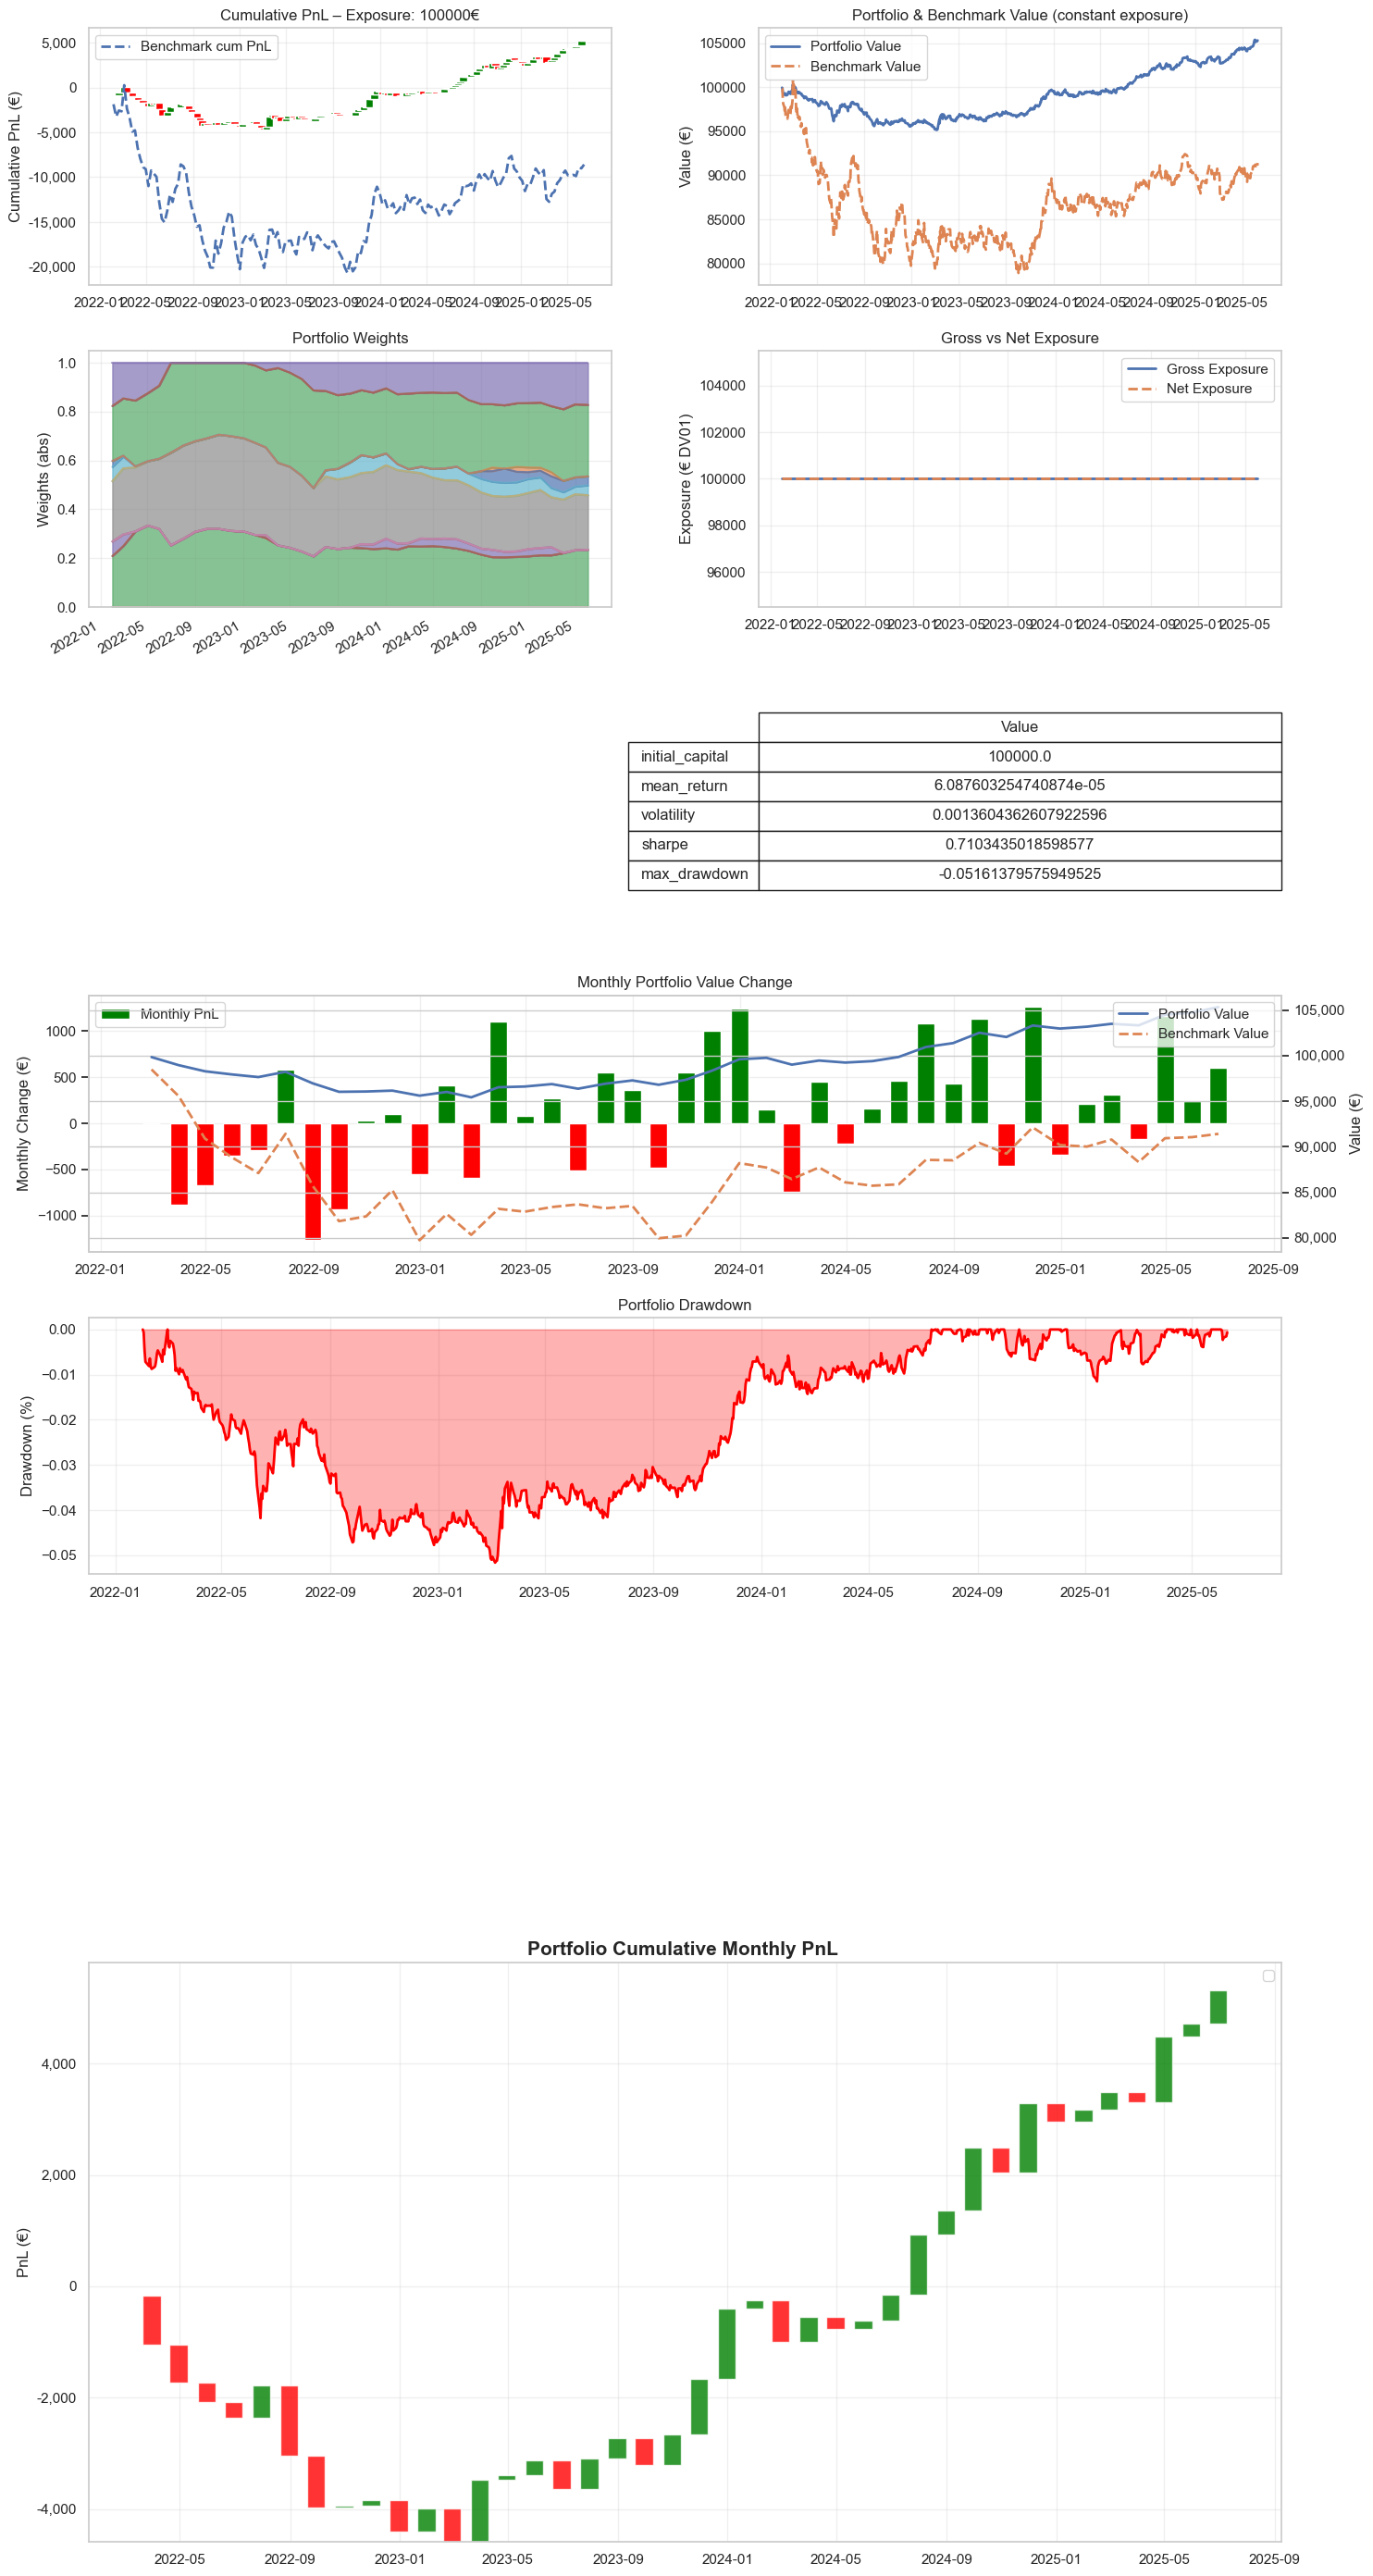

In [13]:


start_date = "2022-01-01"
end_date   = "2025-06-10"


tspf = TimeSeriesPortfolio(
    data_completed,
    start_date,
    end_date,
    rebalance_freq="1M",
    long_only=True,
    lamb=40,
    benchmark="ew",
    ridge=1,
    window_days=120  # ~ daily data per rebalance   
    )

tspf.generate_portfolios()

viz = PortfolioDashboardVisualizer(tspf)
viz.plot_dashboard()